In [1]:
# ============================================================
# F1M1 — Módulo 1: EDA Leonali
# Notebook 04 — KPIs clásicos de retail
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

df = pd.read_parquet('../data/processed/Dataset1_anonimizado.parquet')
df['precio_unitario'] = df['Costo_Venta'] / df['Piezas_Entregadas'].replace(0, np.nan)
df['año'] = df['FechaProceso'].dt.year
df['mes'] = df['FechaProceso'].dt.month

print(f"✓ Dataset cargado: {df.shape}")


✓ Dataset cargado: (581306, 18)


KPI 1 — TICKET PROMEDIO

Global:
  Media:   $  5,445.72
  Mediana: $  1,249.43
  → Usar mediana como referencia (distribución log-normal)

Por Canal1:
                      mean   median   count
Canal1                                     
Club de Precios   14120.33  4141.56   38446
Conveniencia       3960.48  2651.13   12918
Maquinas Vending   1559.55  1600.00     191
Autoservicio       5289.34  1416.96  473724
Food Service       3065.86   580.00   17869
Mercados            491.61   272.00     706
Otros               279.79     0.00   37452

Evolución del ticket mediano por año:
año
2012     367.00
2013     155.82
2014     147.00
2015    2124.64
2016    1439.05
2017    1579.20
2018    1669.36
2019    1658.19
2020    1389.20
2021    1525.70
2022    1953.83


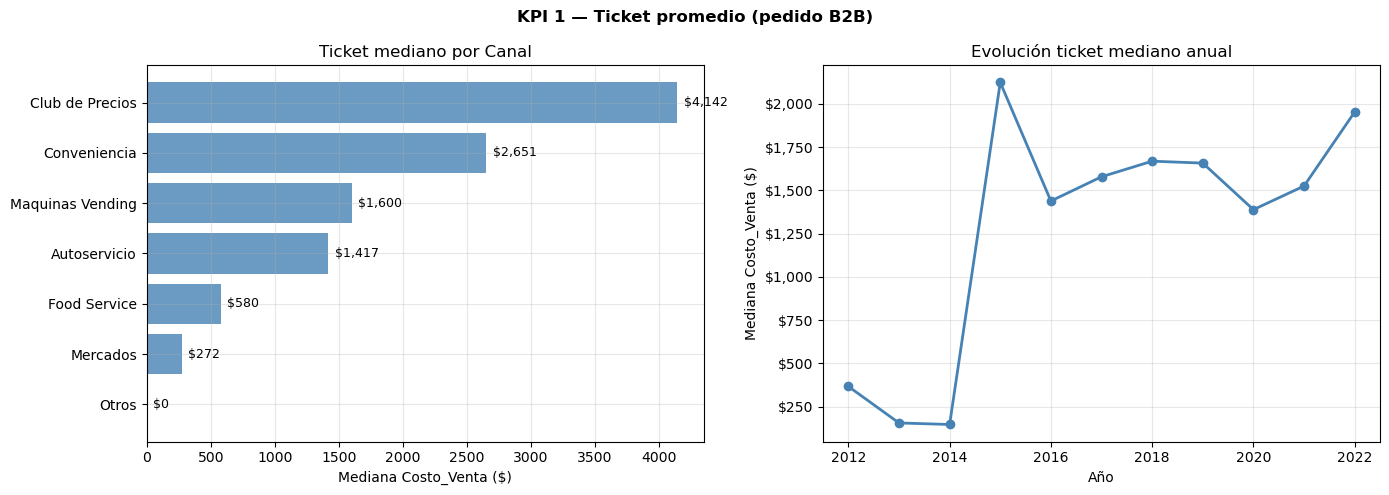

In [2]:
# ============================================================
# KPI 1 — TICKET PROMEDIO (PEDIDO B2B)
# ============================================================
# Definición: valor promedio por transacción de sell-in
# Fórmula: sum(Costo_Venta) / count(transacciones)
# Granularidad disponible: por día × cliente × producto

print("=" * 55)
print("KPI 1 — TICKET PROMEDIO")
print("=" * 55)

# Global
ticket_global = df['Costo_Venta'].mean()
ticket_mediana = df['Costo_Venta'].median()

print(f"\nGlobal:")
print(f"  Media:   ${ticket_global:>10,.2f}")
print(f"  Mediana: ${ticket_mediana:>10,.2f}")
print(f"  → Usar mediana como referencia (distribución log-normal)")

# Por canal
print(f"\nPor Canal1:")
ticket_canal = df.groupby('Canal1')['Costo_Venta'].agg(['mean','median','count'])\
                 .round(2).sort_values('median', ascending=False)
print(ticket_canal.to_string())

# Por año — ¿el ticket promedio ha crecido?
print(f"\nEvolución del ticket mediano por año:")
ticket_año = df.groupby('año')['Costo_Venta'].median().round(2)
print(ticket_año.to_string())

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ticket_canal_plot = df.groupby('Canal1')['Costo_Venta'].median()\
                      .sort_values(ascending=True)
ax.barh(ticket_canal_plot.index, ticket_canal_plot.values,
        color='steelblue', alpha=0.8)
ax.set_title('Ticket mediano por Canal')
ax.set_xlabel('Mediana Costo_Venta ($)')
for i, v in enumerate(ticket_canal_plot.values):
    ax.text(v + 50, i, f'${v:,.0f}', va='center', fontsize=9)

ax = axes[1]
ax.plot(ticket_año.index, ticket_año.values, 
        marker='o', linewidth=2, color='steelblue')
ax.set_title('Evolución ticket mediano anual')
ax.set_xlabel('Año')
ax.set_ylabel('Mediana Costo_Venta ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.suptitle('KPI 1 — Ticket promedio (pedido B2B)', fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/04_kpi_ticket_promedio.png', dpi=150, bbox_inches='tight')
plt.show()

KPI 2 — SHARE DE CATEGORÍA

Ventas totales: $3165.6M

Share por Categoría:
  Espinaca              35.56%  █████████████████
  Botana                26.03%  █████████████
  Hojas                 18.96%  █████████
  Ensalada              14.92%  ███████
  Abarrotes              1.71%  
  Espinaca Organica      1.04%  
  Fresco                 0.79%  
  Smoothies              0.37%  
  Adicional              0.25%  
  Sopas                  0.24%  
  Jugos                  0.13%  

Share por Canal:
  Autoservicio          79.15%  ███████████████████████████████████████
  Club de Precios       17.15%  ████████
  Food Service           1.73%  
  Conveniencia           1.62%  
  Otros                  0.33%  
  Mercados               0.01%  
  Maquinas Vending       0.01%  


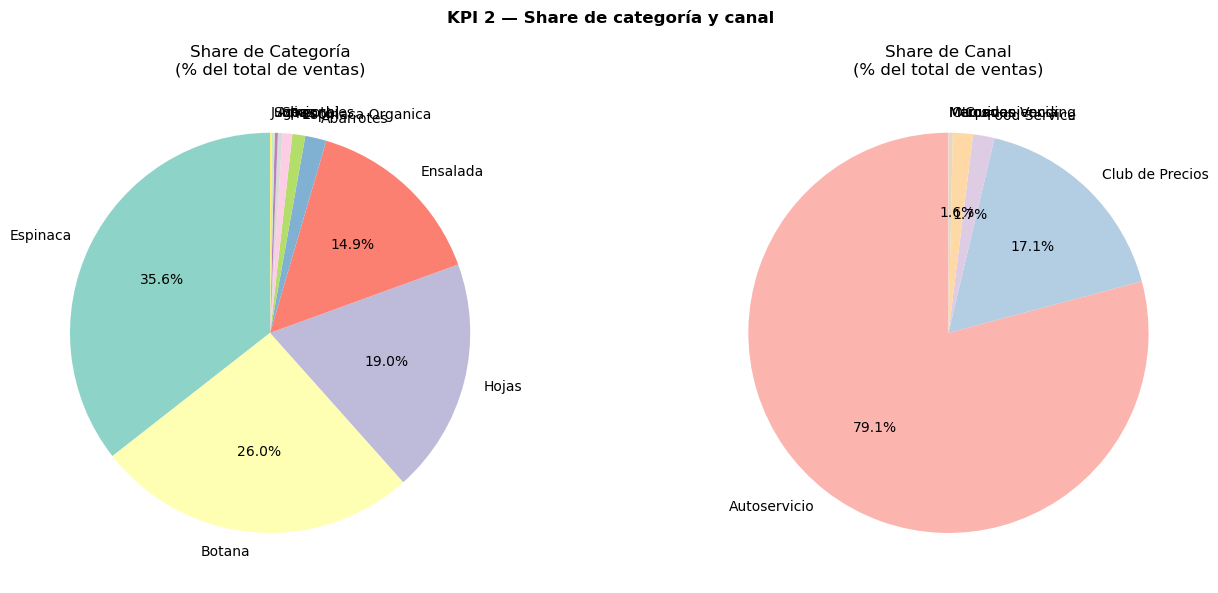

In [3]:
# ============================================================
# KPI 2 — SHARE DE CATEGORÍA
# ============================================================
# Definición: % de ventas que representa cada categoría
# Fórmula: ventas_categoria / ventas_totales * 100

print("=" * 55)
print("KPI 2 — SHARE DE CATEGORÍA")
print("=" * 55)

ventas_total = df['Costo_Venta'].sum()

share_cat = df.groupby('Categoria1')['Costo_Venta'].sum()
share_cat = (share_cat / ventas_total * 100).sort_values(ascending=False).round(2)

print(f"\nVentas totales: ${ventas_total/1e6:.1f}M")
print(f"\nShare por Categoría:")
for cat, pct in share_cat.items():
    bar = "█" * int(pct/2)
    print(f"  {cat:<20} {pct:>6.2f}%  {bar}")

# Share por canal
share_canal = df.groupby('Canal1')['Costo_Venta'].sum()
share_canal = (share_canal / ventas_total * 100).sort_values(ascending=False).round(2)

print(f"\nShare por Canal:")
for canal, pct in share_canal.items():
    bar = "█" * int(pct/2)
    print(f"  {canal:<20} {pct:>6.2f}%  {bar}")

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
colors = plt.cm.Set3(np.linspace(0, 1, len(share_cat)))
wedges, texts, autotexts = ax.pie(
    share_cat.values, labels=share_cat.index,
    autopct=lambda p: f'{p:.1f}%' if p > 2 else '',
    colors=colors, startangle=90)
ax.set_title('Share de Categoría\n(% del total de ventas)')

ax = axes[1]
colors2 = plt.cm.Pastel1(np.linspace(0, 1, len(share_canal)))
ax.pie(share_canal.values, labels=share_canal.index,
       autopct=lambda p: f'{p:.1f}%' if p > 1 else '',
       colors=colors2, startangle=90)
ax.set_title('Share de Canal\n(% del total de ventas)')

plt.suptitle('KPI 2 — Share de categoría y canal', fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/04_kpi_share.png', dpi=150, bbox_inches='tight')
plt.show()


Clientes:
  Total Clientes: 130
  15 Clientes (11.5%) generan el 80% de ventas
  Top 5 por ventas:
    592b16da8cc2: $856.2M (27.0%)
    171ba04ee475: $275.9M (8.7%)
    7700a1584ccd: $173.9M (5.5%)
    d0766a56341b: $165.0M (5.2%)
    2abe4af02195: $150.3M (4.7%)

Productos:
  Total Productos: 233
  31 Productos (13.3%) generan el 80% de ventas
  Top 5 por ventas:
    PT000130: $543.8M (17.2%)
    PT000147: $162.5M (5.1%)
    PT000070: $159.2M (5.0%)
    PTD00056: $145.9M (4.6%)
    PT000037: $125.9M (4.0%)


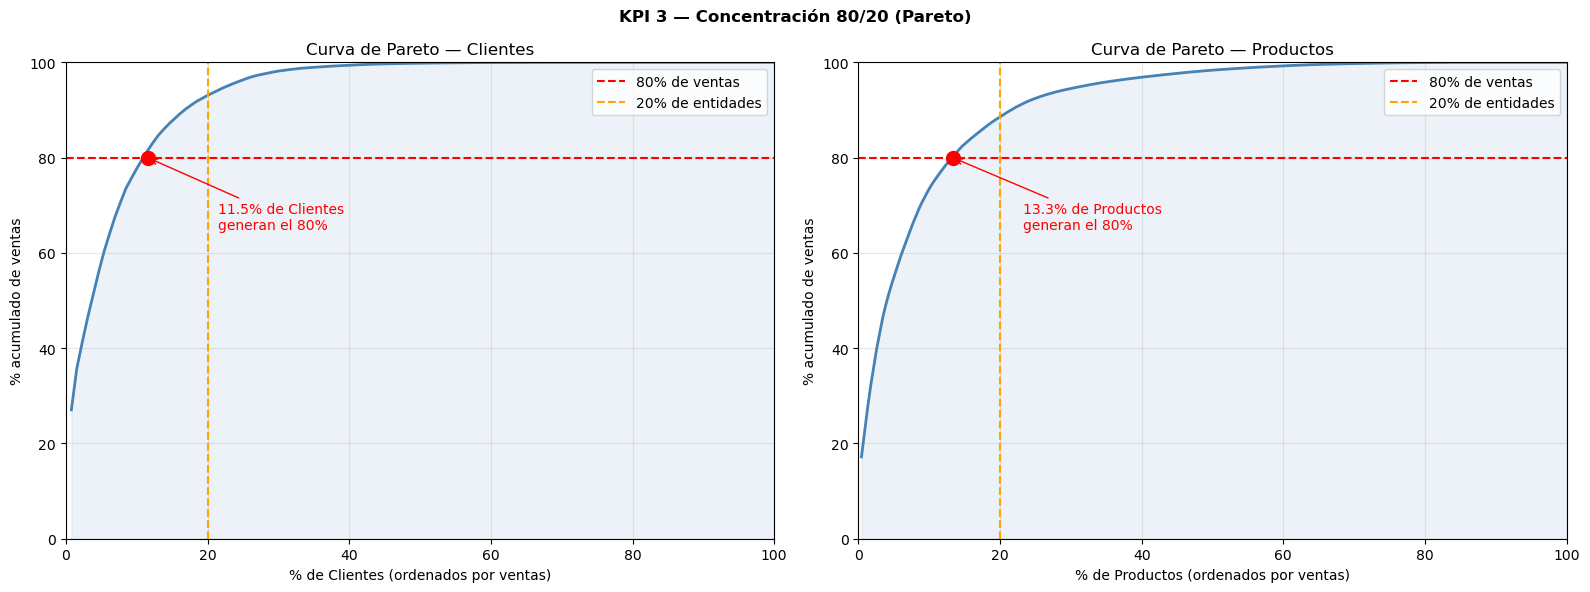

In [4]:
# ============================================================
# KPI 3 — CONCENTRACIÓN 80/20 (PARETO)
# ============================================================
# ¿Qué % de clientes genera el 80% de las ventas?
# ¿Qué % de productos genera el 80% de las ventas?

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, dimension, label in zip(axes,
    ['IdCliente', 'IdProducto'],
    ['Clientes', 'Productos']):

    ventas_dim = df.groupby(dimension)['Costo_Venta'].sum()\
                   .sort_values(ascending=False)
    total = ventas_dim.sum()
    acumulado = (ventas_dim.cumsum() / total * 100)
    pct_entidades = np.arange(1, len(ventas_dim)+1) / len(ventas_dim) * 100

    ax.plot(pct_entidades, acumulado.values,
            color='steelblue', linewidth=2)
    ax.axhline(80, color='red', linestyle='--', linewidth=1.5,
               label='80% de ventas')
    ax.axvline(20, color='orange', linestyle='--', linewidth=1.5,
               label='20% de entidades')

    # Encontrar el punto 80%
    idx_80 = np.searchsorted(acumulado.values, 80)
    pct_para_80 = pct_entidades[idx_80]
    ax.scatter(pct_para_80, 80, color='red', s=100, zorder=5)
    ax.annotate(f'{pct_para_80:.1f}% de {label}\ngeneran el 80%',
                xy=(pct_para_80, 80),
                xytext=(pct_para_80+10, 65),
                fontsize=10, color='red',
                arrowprops=dict(arrowstyle='->', color='red'))

    ax.fill_between(pct_entidades, acumulado.values,
                    alpha=0.1, color='steelblue')
    ax.set_xlabel(f'% de {label} (ordenados por ventas)')
    ax.set_ylabel('% acumulado de ventas')
    ax.set_title(f'Curva de Pareto — {label}')
    ax.legend()
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)

    # Stats
    n_para_80 = idx_80 + 1
    print(f"\n{label}:")
    print(f"  Total {label}: {len(ventas_dim)}")
    print(f"  {n_para_80} {label} ({pct_para_80:.1f}%) generan el 80% de ventas")
    top5 = ventas_dim.head(5)
    print(f"  Top 5 por ventas:")
    for ent, val in top5.items():
        print(f"    {ent}: ${val/1e6:.1f}M ({val/total*100:.1f}%)")

plt.suptitle('KPI 3 — Concentración 80/20 (Pareto)', fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/04_kpi_pareto.png', dpi=150, bbox_inches='tight')
plt.show()

KPI 4 — CLIENTES ACTIVOS Y VENTAS POR CLIENTE

KPIs por año:
      clientes_activos  venta_por_cliente  pedidos_por_cliente
año                                                           
2012                21             3335.0                  3.0
2013                28           773627.0               1072.0
2014                33           868271.0                878.0
2015                43           682072.0                212.0
2016                59           598822.0                276.0
2017                60           966221.0                461.0
2018                62          1238851.0                488.0
2019                82           265459.0                244.0
2020                86           371430.0                306.0
2021                77           622595.0                376.0
2022                78           673423.0                251.0


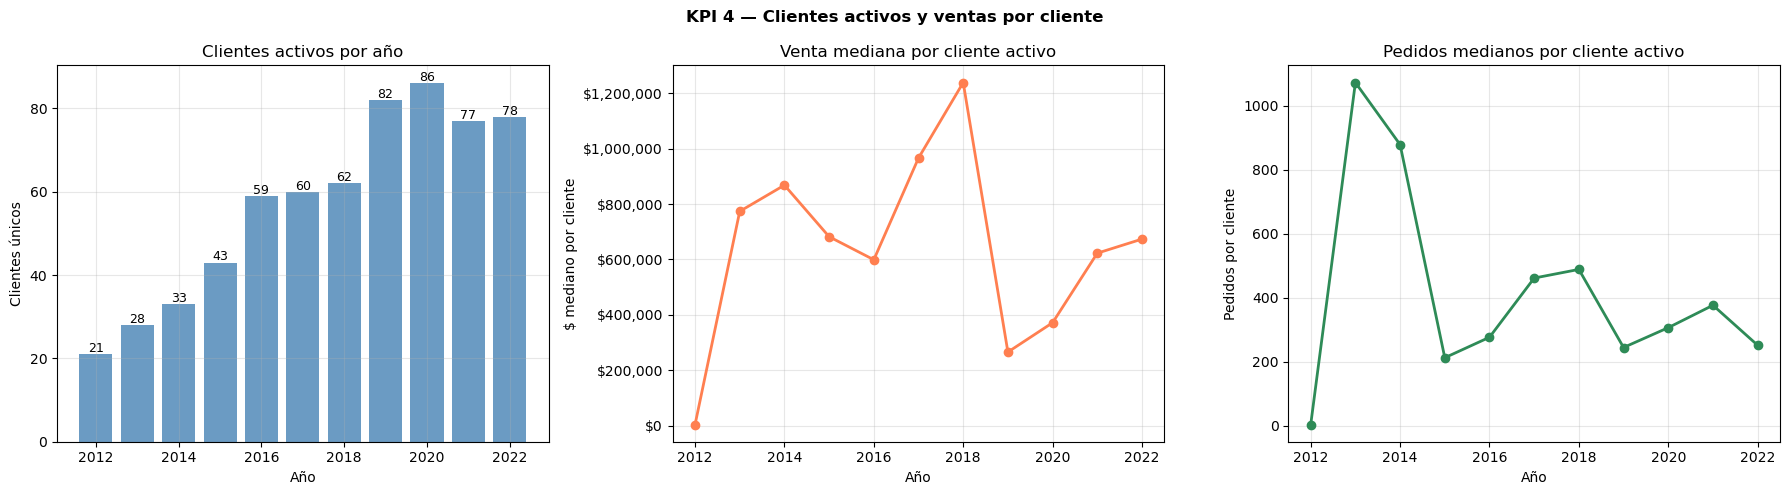

In [5]:
# ============================================================
# KPI 4 — VENTAS POR CLIENTE ACTIVO Y FRECUENCIA DE PEDIDO
# ============================================================

# Definir "cliente activo" por año
print("=" * 55)
print("KPI 4 — CLIENTES ACTIVOS Y VENTAS POR CLIENTE")
print("=" * 55)

resumen_clientes = df.groupby(['año', 'IdCliente']).agg(
    ventas        = ('Costo_Venta', 'sum'),
    pedidos       = ('Costo_Venta', 'count'),
    dias_activo   = ('FechaProceso', lambda x: (x.max()-x.min()).days + 1)
).reset_index()

kpi_anual = resumen_clientes.groupby('año').agg(
    clientes_activos = ('IdCliente', 'count'),
    venta_por_cliente = ('ventas', 'median'),
    pedidos_por_cliente = ('pedidos', 'median')
).round(0)

print(f"\nKPIs por año:")
print(kpi_anual.to_string())

# Visualización
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.bar(kpi_anual.index, kpi_anual['clientes_activos'],
       color='steelblue', alpha=0.8)
ax.set_title('Clientes activos por año')
ax.set_xlabel('Año')
ax.set_ylabel('Clientes únicos')
for i, (yr, v) in enumerate(kpi_anual['clientes_activos'].items()):
    ax.text(yr, v+0.5, str(int(v)), ha='center', fontsize=9)

ax = axes[1]
ax.plot(kpi_anual.index, kpi_anual['venta_por_cliente'],
        marker='o', linewidth=2, color='coral')
ax.set_title('Venta mediana por cliente activo')
ax.set_xlabel('Año')
ax.set_ylabel('$ mediano por cliente')
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))

ax = axes[2]
ax.plot(kpi_anual.index, kpi_anual['pedidos_por_cliente'],
        marker='o', linewidth=2, color='seagreen')
ax.set_title('Pedidos medianos por cliente activo')
ax.set_xlabel('Año')
ax.set_ylabel('Pedidos por cliente')

plt.suptitle('KPI 4 — Clientes activos y ventas por cliente',
             fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/04_kpi_clientes_activos.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# ============================================================
# RESUMEN — KPIs CALCULADOS
# ============================================================

print("=" * 60)
print("RESUMEN KPIs — LEONALI")
print("=" * 60)

print("""
KPI 1 — TICKET PROMEDIO (pedido B2B):
  • Global mediana: $1,249 por transacción
  • Canal más alto: Club de Precios $4,142 (pedidos grandes)
  • Canal más bajo: Otros $0 (registros sin valor)
  • ⚠️  2012-2014 no comparable — cambio de granularidad en 2015

KPI 2 — SHARE DE CATEGORÍA:
  • Top 4 concentran 95.5% de ventas
  • Espinaca: 35.6% | Botana: 26.0% | Hojas: 19.0% | Ensalada: 14.9%
  • Autoservicio: 79.1% del total de ventas

KPI 3 — CONCENTRACIÓN 80/20:
  • 15 clientes (11.5%) generan el 80% de ventas
  • 31 productos (13.3%) generan el 80% de ventas
  • Riesgo de concentración alto — key account management crítico

KPI 4 — CLIENTES ACTIVOS:
  • Crecimiento de 21 (2012) a 86 (2021) clientes activos
  • COVID atrajo más clientes nuevos, no tickets más grandes
  • Venta pico por cliente: 2018-2019 ($950K-$1.2M mediano)
""")

print("KPIs de gestión comercial avanzada (futuros módulos):")
print("  • Crecimiento YoY por canal/categoría → S5.4 extensión")
print("  • Waterfall de desviación → Módulo 2")
print("  • Forecast de cierre → Módulo 5")
print("  • Penetración de catálogo por formato → Módulo 2")
print("  • Elasticidad precio-volumen → Módulo 7")

RESUMEN KPIs — LEONALI

KPI 1 — TICKET PROMEDIO (pedido B2B):
  • Global mediana: $1,249 por transacción
  • Canal más alto: Club de Precios $4,142 (pedidos grandes)
  • Canal más bajo: Otros $0 (registros sin valor)
  • ⚠️  2012-2014 no comparable — cambio de granularidad en 2015

KPI 2 — SHARE DE CATEGORÍA:
  • Top 4 concentran 95.5% de ventas
  • Espinaca: 35.6% | Botana: 26.0% | Hojas: 19.0% | Ensalada: 14.9%
  • Autoservicio: 79.1% del total de ventas

KPI 3 — CONCENTRACIÓN 80/20:
  • 15 clientes (11.5%) generan el 80% de ventas
  • 31 productos (13.3%) generan el 80% de ventas
  • Riesgo de concentración alto — key account management crítico

KPI 4 — CLIENTES ACTIVOS:
  • Crecimiento de 21 (2012) a 86 (2021) clientes activos
  • COVID atrajo más clientes nuevos, no tickets más grandes
  • Venta pico por cliente: 2018-2019 ($950K-$1.2M mediano)

KPIs de gestión comercial avanzada (futuros módulos):
  • Crecimiento YoY por canal/categoría → S5.4 extensión
  • Waterfall de desviació